In [10]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter
from math import log2

data = pd.read_csv('../data/konswkwencje_zbior_30_AB_do_porownania.csv')

In [11]:
data = data[["id", "Ilość", "Takie same/nowe/inne", "bardziej/mniej podobne", "bardziej/mniej poważne", "Różnica w ocenie powagi konsekwensji", "Dodatkowe uwagi/", "annotator_group"]]

In [12]:
data = data[data['id'] <= 111]
data

,id,Ilość,Takie same/nowe/inne,bardziej/mniej podobne,bardziej/mniej poważne,Różnica w ocenie powagi konsekwensji,Dodatkowe uwagi/,annotator_group
0,8,Więcej,Bardziej dokładne,Podobne,Bardziej poważne,Spadła,NaN,komunikacja
1,8,Więcej,Bardziej dokładne,Różne,Bardziej poważne,Bez zmian,NaN,rodzic
2,8,Mniej,Mniej dokładne,Podobne,Mniej poważne,Bez zmian,Spłycenie z poziomu ogólnego problemu na jedno...,psycholog
3,8,Mniej,Mniej dokładne,Różne,Mniej poważne,Wzrosła,Spłycenie z poziomu ogólnego problemu na jedno...,nauczyciel
4,8,Więcej,Bardziej dokładne,Podobne,Bez zmian,Spadła,NaN,nastolatek
...,...,...,...,...,...,...,...,...
105,111,Więcej,Bardziej dokładne,Podobne,Bardziej poważne,Wzrosła,NaN,komunikacja
106,111,Bez zmian,Bardziej dokładne,Podobne,Bardziej poważne,Bez zmian,Pojawiło się uczucie stresu,rodzic
107,111,Więcej,Bardziej dokładne,Podobne,Bardziej poważne,Bez zmian,NaN,psycholog
108,111,Mniej,Mniej dokładne,Podobne,Mniej poważne,Wzrosła,Pojawił się aspekt grupy,nauczyciel


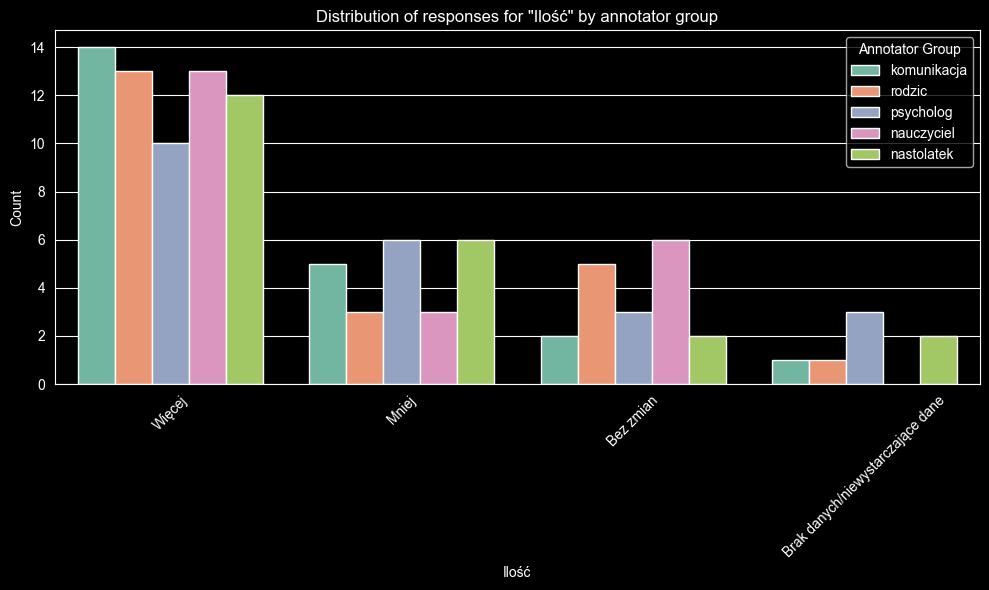

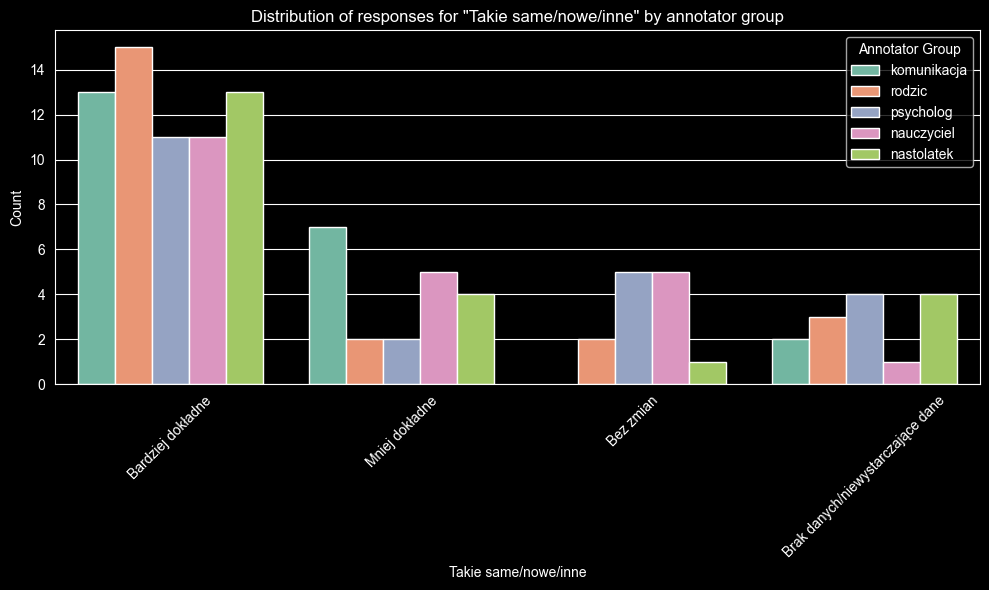

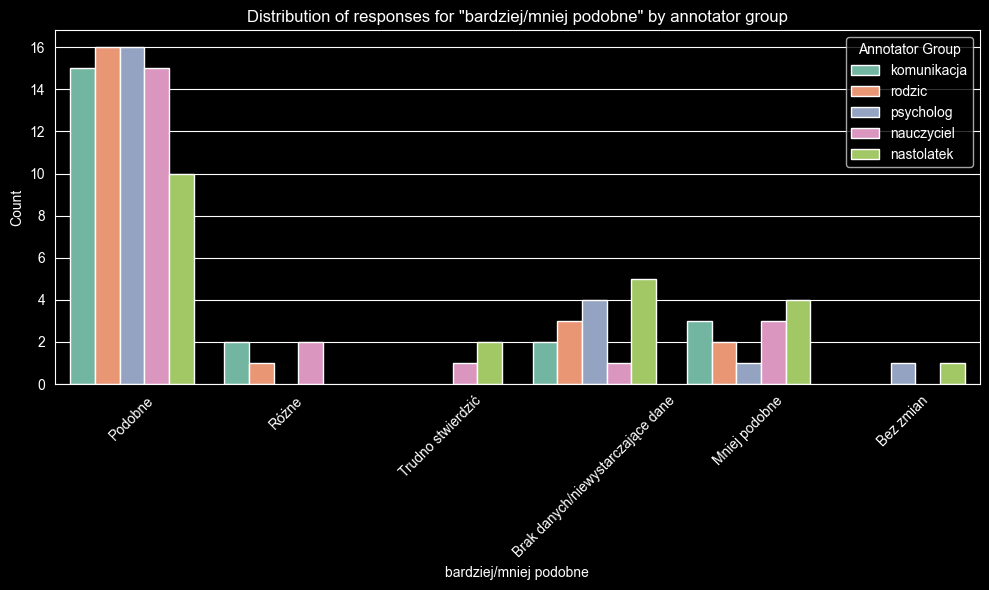

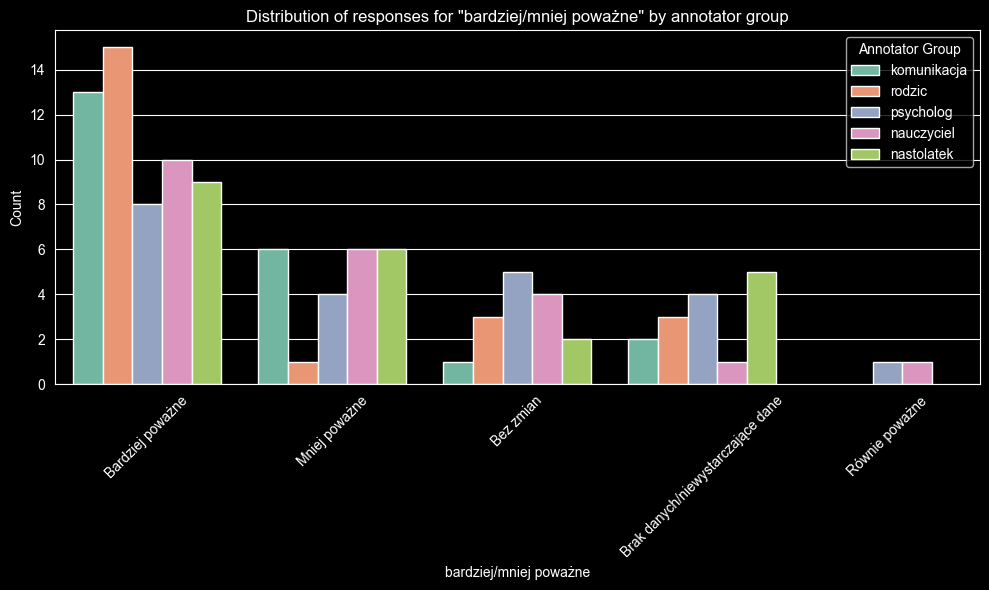

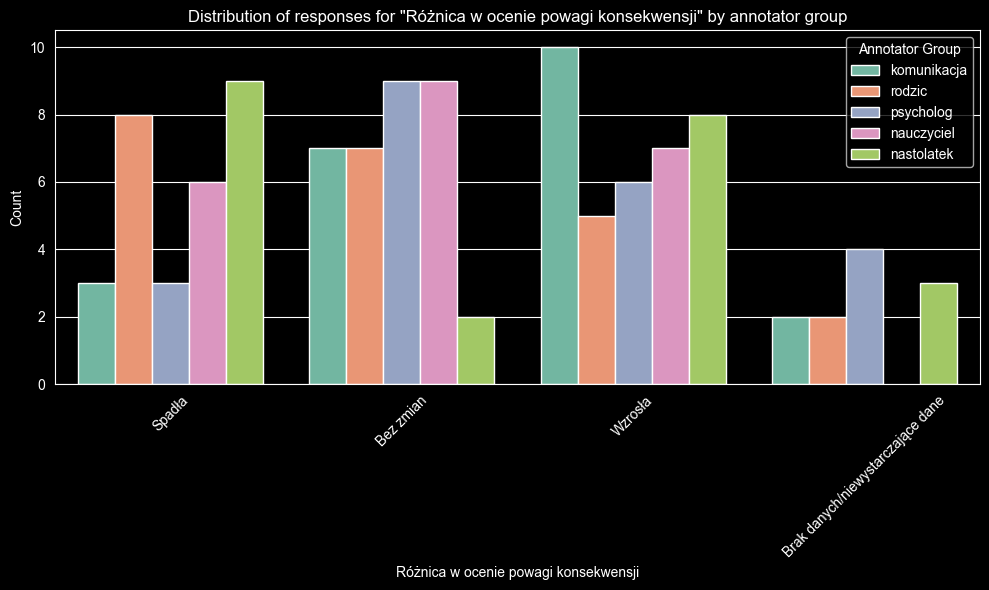

In [13]:
columns_to_analyze = ["Ilość", "Takie same/nowe/inne", "bardziej/mniej podobne", "bardziej/mniej poważne", "Różnica w ocenie powagi konsekwensji"]
for column in columns_to_analyze:
    plt.figure(figsize=(10, 6))
    sns.countplot(data=data, x=column, hue='annotator_group', palette='Set2')
    plt.title(f'Distribution of responses for "{column}" by annotator group')
    plt.xlabel(column)
    plt.ylabel('Count')
    plt.legend(title='Annotator Group')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


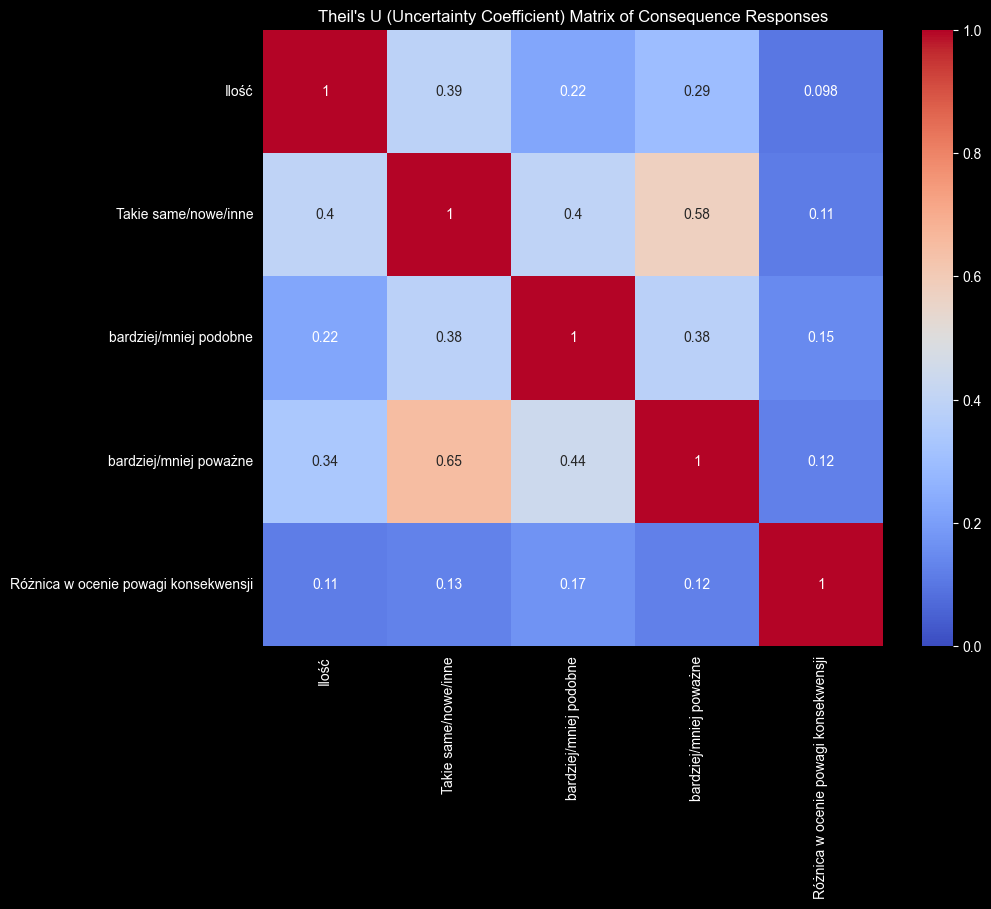

In [14]:
def entropy(x):
    counts = Counter(x)
    total = sum(counts.values())
    return -sum((count / total) * log2(count / total) for count in counts.values())


def conditional_entropy(y, x):
    total = len(x)
    entropy_sum = 0.0

    for x_val in set(x):
        subset_y = [y[i] for i in range(total) if x[i] == x_val]
        entropy_sum += (len(subset_y) / total) * entropy(subset_y)

    return entropy_sum


def theils_u(x, y):
    h_y = entropy(y)
    if h_y == 0:
        return 0.0
    return (h_y - conditional_entropy(y, x)) / h_y


u_matrix = pd.DataFrame(
    index=columns_to_analyze,
    columns=columns_to_analyze,
    dtype=float
)

for col_x in columns_to_analyze:
    for col_y in columns_to_analyze:
        u_matrix.loc[col_x, col_y] = theils_u(
            data[col_x].astype(str).values,
            data[col_y].astype(str).values
        )


plt.figure(figsize=(10, 8))
sns.heatmap(
    u_matrix,
    annot=True,
    cmap='coolwarm',
    vmin=0,
    vmax=1,
    xticklabels=columns_to_analyze,
    yticklabels=columns_to_analyze
)
plt.title("Theil's U (Uncertainty Coefficient) Matrix of Consequence Responses")
plt.show()

In [15]:
cross_tab = pd.crosstab(
    data['bardziej/mniej poważne'],
    data['Takie same/nowe/inne'],
    rownames=['bardziej/mniej poważne'],
    colnames=['Takie same/nowe/inne']
)
cross_tab

Takie same/nowe/inne,Bardziej dokładne,Bez zmian,Brak danych/niewystarczające dane,Mniej dokładne
bardziej/mniej poważne,,,,
Bardziej poważne,53,1,0,1
Bez zmian,3,10,0,2
Brak danych/niewystarczające dane,1,0,14,0
Mniej poważne,5,1,0,17
Równie poważne,1,1,0,0


In [16]:
cross_tab = pd.crosstab(
    data['bardziej/mniej poważne'],
    data['bardziej/mniej podobne'],
    rownames=['bardziej/mniej poważne'],
    colnames=['bardziej/mniej podobne']
)
cross_tab

bardziej/mniej podobne,Bez zmian,Brak danych/niewystarczające dane,Mniej podobne,Podobne,Różne,Trudno stwierdzić
bardziej/mniej poważne,,,,,,
Bardziej poważne,0,0,11,38,3,3
Bez zmian,2,0,0,13,0,0
Brak danych/niewystarczające dane,0,15,0,0,0,0
Mniej poważne,0,0,2,19,2,0
Równie poważne,0,0,0,2,0,0
